# Feature Engineering, Transformation & Class Imbalance Handling

**This notebook completes Task 1 by doing:**
1. Engineered fraud-specific features for `Fraud_Data`:
   - `time_since_signup_hours` — gap between signup and purchase
   - `hour_of_day`, `day_of_week` — temporal patterns
   - `user_transaction_count`, `device_transaction_count` — velocity features
2. One-hot encode categorical columns
3. Scale numeric features with `StandardScaler`
4. Stratified train/test split
5. Apply SMOTE to training sets **only**
6. Save model-ready datasets

> **Prerequisites:** Run `eda_fraud_data.ipynb` and `eda_creditcard.ipynb` first
> so that `data/processed/fraud_data_cleaned.csv` and `data/processed/creditcard_cleaned.csv` exist.

## 1. Setup & Imports

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split  # splits data into train/test
from sklearn.preprocessing import StandardScaler      # normalises numeric features

# imbalanced-learn — for SMOTE
from imblearn.over_sampling import SMOTE

sys.path.append(os.path.join('..'))
from src.preprocessing import add_time_features, add_time_since_signup, add_transaction_velocity

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES_DIR    = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print('✓ Setup complete')

✓ Setup complete


---
## PART A — E-commerce Fraud Data (`Fraud_Data.csv`)
---

## 2. Load Cleaned Fraud Data

In [2]:
# Load the cleaned file saved by eda_fraud_data.ipynb
fraud = pd.read_csv(
    os.path.join(DATA_PROCESSED, 'fraud_data_cleaned.csv'),
    parse_dates=['signup_time', 'purchase_time']
)
print(f"Loaded: {fraud.shape}")
fraud.head(3)

Loaded: (151112, 13)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.496895,0,52093,Unknown
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.138961,0,93447,Unknown
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.501505,0,105818,Unknown


## 3. Feature Engineering

### 3.1 Time Since Signup

**Why this feature matters for fraud:**

> Fraudsters create fake accounts and immediately make purchases.
> A legitimate user normally waits hours, days, or weeks before buying.

`time_since_signup_hours = (purchase_time - signup_time).total_seconds() / 3600`

A value close to 0 is a major fraud signal.

In [3]:
fraud = add_time_since_signup(fraud)

print("time_since_signup_hours — statistics:")
print(fraud['time_since_signup_hours'].describe())

time_since_signup_hours — statistics:
count    151112.000000
mean       1370.008125
std         868.406422
min           0.000278
25%         607.431528
50%        1368.429306
75%        2123.479028
max        2879.992222
Name: time_since_signup_hours, dtype: float64


In [4]:
# Is a short time since signup actually linked to higher fraud?
# Let's bucket the hours and check the fraud rate per bucket.
fraud['signup_bucket'] = pd.cut(
    fraud['time_since_signup_hours'],
    bins=[0, 1, 24, 168, float('inf')],
    labels=['< 1 hr', '1–24 hrs', '1–7 days', '> 7 days']
)

bucket_stats = (
    fraud.groupby('signup_bucket', observed=True)['class']
    .agg(total='count', fraud_count='sum')
    .assign(fraud_rate=lambda x: x['fraud_count'] / x['total'] * 100)
)
print("Fraud rate by time since signup:")
print(bucket_stats.to_string())

Fraud rate by time since signup:
                total  fraud_count  fraud_rate
signup_bucket                                 
< 1 hr           7641         7604   99.515770
1–24 hrs         1117           44    3.939123
1–7 days         7082          316    4.462016
> 7 days       135272         6187    4.573748


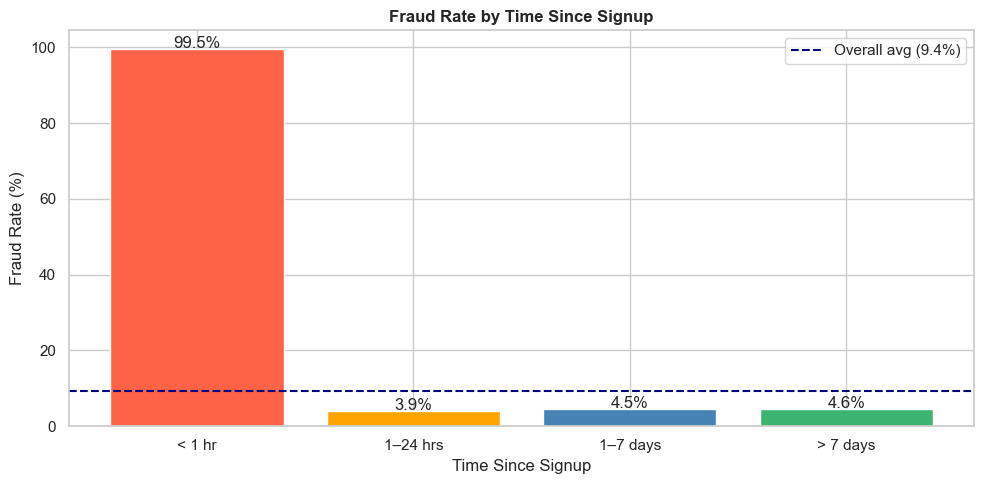

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    bucket_stats.index.astype(str),
    bucket_stats['fraud_rate'],
    color=['tomato', 'orange', 'steelblue', 'mediumseagreen'],
    edgecolor='white'
)
ax.set_title('Fraud Rate by Time Since Signup', fontsize=12, fontweight='bold')
ax.set_xlabel('Time Since Signup')
ax.set_ylabel('Fraud Rate (%)')
ax.axhline(fraud['class'].mean() * 100, color='navy', linestyle='--',
           label=f"Overall avg ({fraud['class'].mean()*100:.1f}%)")
ax.legend()
for i, (_, row) in enumerate(bucket_stats.iterrows()):
    ax.text(i, row['fraud_rate'] + 0.3, f"{row['fraud_rate']:.1f}%", ha='center')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fraud_rate_signup_time.png'), dpi=150, bbox_inches='tight')
plt.show()

fraud = fraud.drop(columns=['signup_bucket'])

### 3.2 Hour of Day & Day of Week

**Why these matter:**
- `hour_of_day` (0–23): fraud may cluster at unusual hours (e.g. 2–4 AM)
- `day_of_week` (0=Monday, 6=Sunday): certain days may have different fraud patterns

In [6]:
# add_time_features() from src/preprocessing.py:
#   hour_of_day  = purchase_time.dt.hour         (0–23)
#   day_of_week  = purchase_time.dt.dayofweek    (0=Mon … 6=Sun)
fraud = add_time_features(fraud)

print("hour_of_day  range:", fraud['hour_of_day'].min(), '–', fraud['hour_of_day'].max())
print("day_of_week  range:", fraud['day_of_week'].min(), '–', fraud['day_of_week'].max(), "(0=Mon, 6=Sun)")

hour_of_day  range: 0 – 23
day_of_week  range: 0 – 6 (0=Mon, 6=Sun)


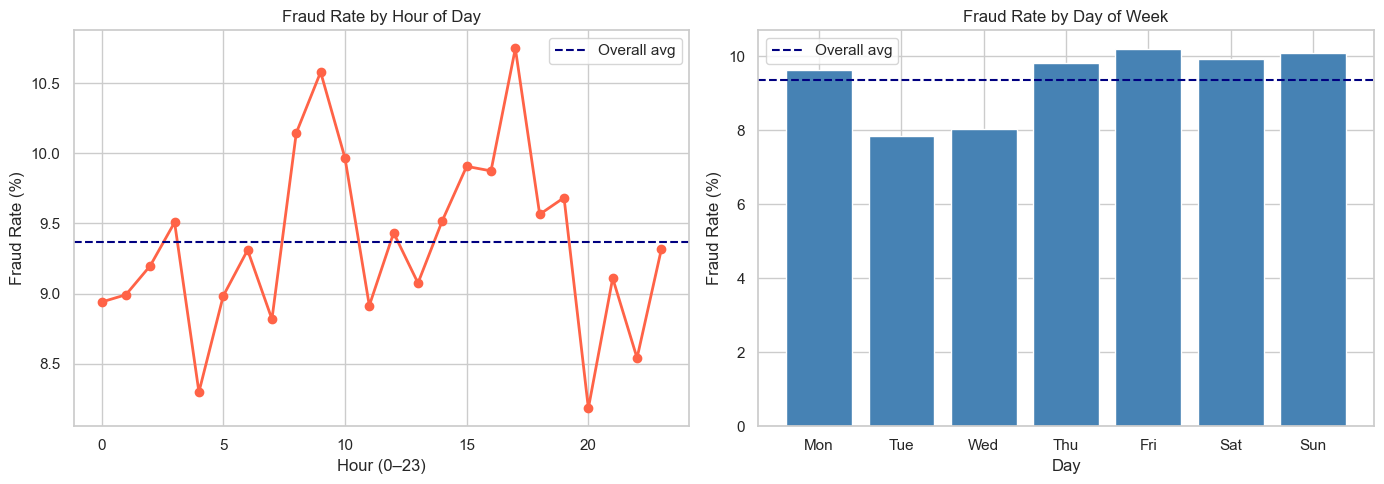

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = (
    fraud.groupby('hour_of_day')['class']
    .agg(total='count', fraud_count='sum')
    .assign(fraud_rate=lambda x: x['fraud_count'] / x['total'] * 100)
)
axes[0].plot(hourly.index, hourly['fraud_rate'], 'o-', color='tomato', linewidth=2)
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(fraud['class'].mean() * 100, color='navy', linestyle='--', label='Overall avg')
axes[0].legend()

dow_fraud = (
    fraud.groupby('day_of_week')['class']
    .agg(total='count', fraud_count='sum')
    .assign(fraud_rate=lambda x: x['fraud_count'] / x['total'] * 100)
)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(day_labels, dow_fraud['fraud_rate'], color='steelblue', edgecolor='white')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(fraud['class'].mean() * 100, color='navy', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'time_features_fraud.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Transaction Velocity (per User & Device)

**Why velocity matters:**
- **Card testing**: fraudsters make many small purchases rapidly to verify a card works.
- **Device reuse**: one stolen device used across many fake accounts is a red flag.

`user_transaction_count` = total purchases by this `user_id` in the dataset  
`device_transaction_count` = total purchases from this `device_id`

> A higher count doesn't always mean fraud, but combined with other features it's a strong signal.

In [8]:
# add_transaction_velocity() uses groupby().transform('count'):
# it maps the group SIZE back to each individual row, preserving the original index.
fraud = add_transaction_velocity(fraud)

print("user_transaction_count:")
print(fraud['user_transaction_count'].describe())
print()
print("device_transaction_count:")
print(fraud['device_transaction_count'].describe())

user_transaction_count:
count    151112.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: user_transaction_count, dtype: float64

device_transaction_count:
count    151112.000000
mean          1.684367
std           2.616954
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: device_transaction_count, dtype: float64


## 4. Prepare Final Feature Set

### 4.1 Drop Identifier & Replaced Columns

We drop columns that are either:
- **Identifiers** (not predictive): `user_id`
- **Replaced by engineered features**: `signup_time`, `purchase_time` → replaced by `time_since_signup_hours`, `hour_of_day`, `day_of_week`
- **Replaced by better form**: `ip_address` → replaced by `ip_int` + `country`; `device_id` → replaced by `device_transaction_count`

In [9]:
cols_to_drop = ['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time']
fraud_model  = fraud.drop(columns=cols_to_drop)

print("Columns kept for modelling:")
for col in fraud_model.columns:
    print(f"  {col}")
print(f"\nShape: {fraud_model.shape}")

Columns kept for modelling:
  purchase_value
  source
  browser
  sex
  age
  class
  ip_int
  country
  time_since_signup_hours
  hour_of_day
  day_of_week
  user_transaction_count
  device_transaction_count

Shape: (151112, 13)


### 4.2 One-Hot Encode Categorical Columns

**Why one-hot encoding?**  
ML models work with numbers, not text. One-hot encoding converts a column like `source` (SEO, Ads, Direct) 
into three binary columns: `source_SEO`, `source_Ads`, `source_Direct`.

**Why `drop_first=True`?**  
If `source_SEO=0` and `source_Ads=0`, we already know it's `source_Direct`.
The third column is redundant — dropping it prevents multicollinearity in linear models.

In [10]:
cat_cols = ['source', 'browser', 'sex', 'country']
print("Unique values per categorical column before encoding:")
for col in cat_cols:
    print(f"  {col}: {fraud_model[col].nunique()} unique values")

fraud_model = pd.get_dummies(fraud_model, columns=cat_cols, drop_first=True, dtype=int)

print(f"\nShape after one-hot encoding: {fraud_model.shape}")
encoded_cols = [c for c in fraud_model.columns if '_' in c]
print(f"Sample new columns: {encoded_cols[:10]}")

Unique values per categorical column before encoding:
  source: 3 unique values
  browser: 5 unique values
  sex: 2 unique values
  country: 182 unique values

Shape after one-hot encoding: (151112, 197)
Sample new columns: ['purchase_value', 'ip_int', 'time_since_signup_hours', 'hour_of_day', 'day_of_week', 'user_transaction_count', 'device_transaction_count', 'source_Direct', 'source_SEO', 'browser_FireFox']


### 4.3 Separate Features (X) and Target (y)

In [11]:
# X = all columns except the target
# y = the 'class' column we want to predict (0 or 1)
X = fraud_model.drop(columns=['class'])
y = fraud_model['class']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"Fraud rate in y  : {y.mean()*100:.2f}%")

Feature matrix X : (151112, 196)
Target vector  y : (151112,)
Fraud rate in y  : 9.36%


## 5. Stratified Train / Test Split

In [12]:
# train_test_split parameters explained:
#   test_size=0.2   → 20% for testing, 80% for training
#   stratify=y      → CRUCIAL: keeps the same 9.36% fraud rate in BOTH splits
#                     Without stratify, random chance could put most fraud in one split
#   random_state=42 → fixes the random seed so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set : {X_train.shape[0]:,} rows  |  fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set     : {X_test.shape[0]:,} rows  |  fraud rate: {y_test.mean()*100:.2f}%")

Training set : 120,889 rows  |  fraud rate: 9.36%
Test set     : 30,223 rows  |  fraud rate: 9.36%


## 6. Scale Numerical Features

**Why scale?**  
`time_since_signup_hours` can be in the thousands, while `hour_of_day` is only 0–23.
Without scaling, Logistic Regression (and distance-based models) will over-weight the large features.

`StandardScaler` transforms each feature to have **mean=0** and **std=1**:

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

**Critical rule: Fit on training data only, then transform both sets.**  
If we fit on the full dataset, the scaler "learns" from test data — that's **data leakage**.

In [13]:
numeric_cols = [
    'purchase_value', 'age', 'ip_int',
    'time_since_signup_hours', 'hour_of_day', 'day_of_week',
    'user_transaction_count', 'device_transaction_count'
]

scaler  = StandardScaler()

# fit_transform on train: computes mean/std FROM training data, then scales it
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# transform on test: uses the SAME mean/std from training — no leakage
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("✓ Scaling complete (fit on training data only)")
print("\nSample scaled values (first 2 rows):")
print(X_train[numeric_cols[:4]].head(2).to_string())

✓ Scaling complete (fit on training data only)

Sample scaled values (first 2 rows):
       purchase_value       age    ip_int  time_since_signup_hours
50400       -1.416176 -0.599468 -0.580242                -0.354422
95942        0.331494 -1.295842  0.474285                 1.338380


## 7. Handle Class Imbalance — SMOTE

### What is SMOTE?

**SMOTE = Synthetic Minority Oversampling TEchnique**

The problem with simple duplication (random oversampling) is that copying the same fraud rows 
causes overfitting — the model just memorises those exact examples.

SMOTE is smarter:
1. Pick a fraud (minority) sample
2. Find its **k nearest neighbours** among other fraud samples
3. Create a **new synthetic sample** on the line between them

This gives the model more diverse fraud examples without exact duplication.

### Why training data only?

> The test set must reflect the **real world** (9.36% fraud).  
> If we SMOTE the test set, we test on fake data and our metrics are meaningless.  
> Apply SMOTE **before** training, **after** splitting — never touch the test set.

In [14]:
print("Class distribution BEFORE SMOTE (training set):")
print(y_train.value_counts().to_string())
print(f"Fraud rate: {y_train.mean()*100:.2f}%")

Class distribution BEFORE SMOTE (training set):
class
0    109568
1     11321
Fraud rate: 9.36%


In [15]:
# SMOTE(random_state=42)     → reproducible results
# sampling_strategy='auto'   → default: oversamples minority to match majority (50/50)
smote = SMOTE(random_state=42)

# fit_resample: analyses the minority class, creates synthetic samples, returns balanced dataset
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution AFTER SMOTE:")
print(pd.Series(y_train_res).value_counts().to_string())
print(f"\nTraining rows before : {len(X_train):,}")
print(f"Training rows after  : {len(X_train_res):,}")
print(f"New synthetic samples: {len(X_train_res) - len(X_train):,}")

Class distribution AFTER SMOTE:
class
0    109568
1    109568

Training rows before : 120,889
Training rows after  : 219,136
New synthetic samples: 98,247


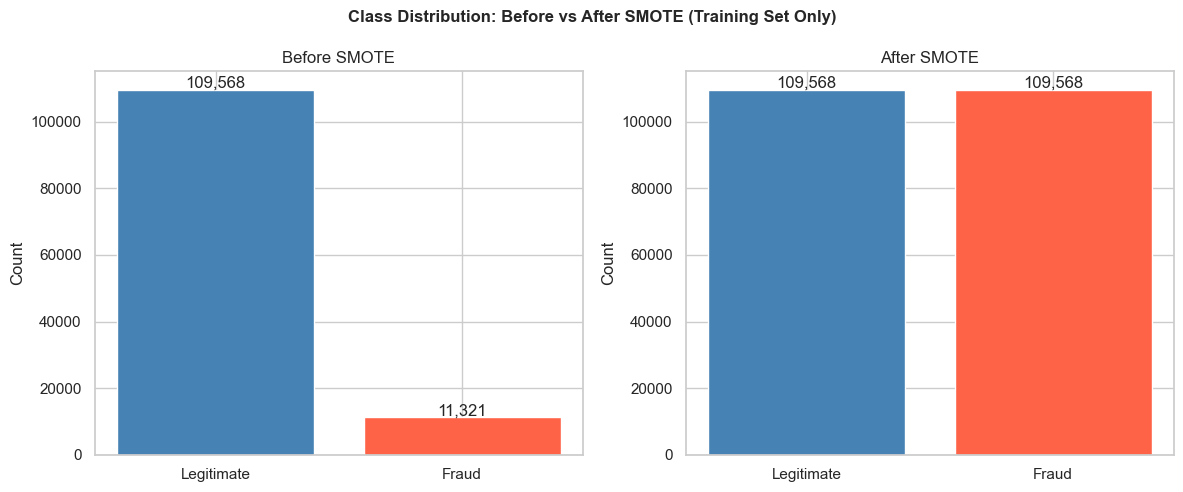

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, title in [
    (axes[0], y_train.value_counts(),              'Before SMOTE'),
    (axes[1], pd.Series(y_train_res).value_counts(), 'After SMOTE')
]:
    ax.bar(['Legitimate', 'Fraud'], counts.values,
           color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f"{v:,}", ha='center')

plt.suptitle('Class Distribution: Before vs After SMOTE (Training Set Only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'smote_fraud.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Fraud Processed Data

In [17]:
X_train_df = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_s  = pd.Series(y_train_res, name='class')
X_test_df  = pd.DataFrame(X_test, columns=X_test.columns)
y_test_s   = y_test.reset_index(drop=True)

X_train_df.to_csv(os.path.join(DATA_PROCESSED, 'fraud_X_train.csv'), index=False)
y_train_s.to_csv( os.path.join(DATA_PROCESSED, 'fraud_y_train.csv'), index=False)
X_test_df.to_csv( os.path.join(DATA_PROCESSED, 'fraud_X_test.csv'),  index=False)
y_test_s.to_csv(  os.path.join(DATA_PROCESSED, 'fraud_y_test.csv'),  index=False)

with open(os.path.join(DATA_PROCESSED, 'fraud_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Fraud data splits saved.")
print(f"  X_train: {X_train_df.shape}  (SMOTE-balanced)")
print(f"  X_test : {X_test_df.shape}  (real-world distribution)")

✓ Fraud data splits saved.
  X_train: (219136, 196)  (SMOTE-balanced)
  X_test : (30223, 196)  (real-world distribution)


---
## PART B — Credit Card Data (`creditcard.csv`)
---

## 9. Load Cleaned Credit Card Data

In [18]:
cc = pd.read_csv(os.path.join(DATA_PROCESSED, 'creditcard_cleaned.csv'))
print(f"Loaded: {cc.shape}")
cc.head(3)

Loaded: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 10. Feature Engineering for Credit Card

The credit card dataset is simpler to engineer:
- `V1–V28` are already PCA-scaled — no transformation needed
- Only `Amount` and `Time` need scaling (they're in raw units)

In [19]:
X_cc = cc.drop(columns=['Class'])
y_cc = cc['Class']

print(f"Features : {X_cc.shape}")
print(f"Target   : {y_cc.shape}  |  Fraud rate: {y_cc.mean()*100:.4f}%")

Features : (283726, 30)
Target   : (283726,)  |  Fraud rate: 0.1667%


## 11. Stratified Train / Test Split

In [20]:
X_cc_tr, X_cc_te, y_cc_tr, y_cc_te = train_test_split(
    X_cc, y_cc,
    test_size=0.2,
    stratify=y_cc,
    random_state=42
)

print(f"CC Training set : {X_cc_tr.shape[0]:,}  |  fraud rate: {y_cc_tr.mean()*100:.4f}%")
print(f"CC Test set     : {X_cc_te.shape[0]:,}  |  fraud rate: {y_cc_te.mean()*100:.4f}%")

CC Training set : 226,980  |  fraud rate: 0.1665%
CC Test set     : 56,746  |  fraud rate: 0.1674%


## 12. Scale Amount and Time

In [21]:
cc_numeric = ['Amount', 'Time']
cc_scaler  = StandardScaler()

X_cc_tr = X_cc_tr.copy()
X_cc_te = X_cc_te.copy()

X_cc_tr[cc_numeric] = cc_scaler.fit_transform(X_cc_tr[cc_numeric])
X_cc_te[cc_numeric] = cc_scaler.transform(X_cc_te[cc_numeric])

print("✓ Amount and Time scaled (fit on training only).")

✓ Amount and Time scaled (fit on training only).


## 13. SMOTE for Credit Card

The imbalance here is extreme: **0.17% fraud (578:1 ratio)**.
SMOTE is essential — even more critical than for the e-commerce dataset.

In [22]:
print("Before SMOTE:")
print(y_cc_tr.value_counts().to_string())
print(f"Fraud rate: {y_cc_tr.mean()*100:.4f}%")

cc_smote = SMOTE(random_state=42)
X_cc_tr_res, y_cc_tr_res = cc_smote.fit_resample(X_cc_tr, y_cc_tr)

print("\nAfter SMOTE:")
print(pd.Series(y_cc_tr_res).value_counts().to_string())
print(f"\nTraining rows before : {len(X_cc_tr):,}")
print(f"Training rows after  : {len(X_cc_tr_res):,}")

Before SMOTE:
Class
0    226602
1       378
Fraud rate: 0.1665%

After SMOTE:
Class
0    226602
1    226602

Training rows before : 226,980
Training rows after  : 453,204


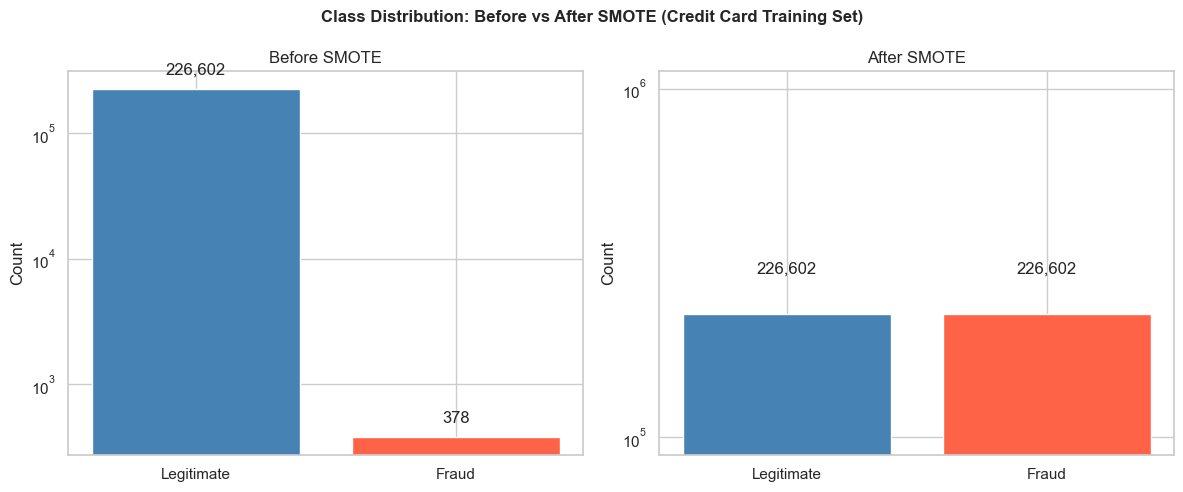

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, title in [
    (axes[0], y_cc_tr.value_counts(),              'Before SMOTE'),
    (axes[1], pd.Series(y_cc_tr_res).value_counts(), 'After SMOTE')
]:
    ax.bar(['Legitimate', 'Fraud'], counts.values,
           color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.set_yscale('log')  # log scale because the imbalance is extreme
    for i, v in enumerate(counts.values):
        ax.text(i, v * 1.3, f"{v:,}", ha='center')

plt.suptitle('Class Distribution: Before vs After SMOTE (Credit Card Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'smote_cc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 14. Save Credit Card Processed Data

In [24]:
X_cc_tr_df = pd.DataFrame(X_cc_tr_res, columns=X_cc_tr.columns)
y_cc_tr_s  = pd.Series(y_cc_tr_res, name='Class')
X_cc_te_df = pd.DataFrame(X_cc_te, columns=X_cc_te.columns)
y_cc_te_s  = y_cc_te.reset_index(drop=True)

X_cc_tr_df.to_csv(os.path.join(DATA_PROCESSED, 'cc_X_train.csv'), index=False)
y_cc_tr_s.to_csv( os.path.join(DATA_PROCESSED, 'cc_y_train.csv'), index=False)
X_cc_te_df.to_csv(os.path.join(DATA_PROCESSED, 'cc_X_test.csv'),  index=False)
y_cc_te_s.to_csv( os.path.join(DATA_PROCESSED, 'cc_y_test.csv'),  index=False)

with open(os.path.join(DATA_PROCESSED, 'cc_scaler.pkl'), 'wb') as f:
    pickle.dump(cc_scaler, f)

print("✓ Credit card splits saved.")
print(f"  X_train: {X_cc_tr_df.shape}  (SMOTE-balanced)")
print(f"  X_test : {X_cc_te_df.shape}  (real-world distribution)")

✓ Credit card splits saved.
  X_train: (453204, 30)  (SMOTE-balanced)
  X_test : (56746, 30)  (real-world distribution)


---
## Task 1 Complete — Summary

### Why SMOTE? (Justification for your report)

| Strategy | Pros | Cons | Verdict |
|----------|------|------|---------|
| **SMOTE** ✅ | Generates diverse synthetic examples; preserves all majority data | Slower; can add noise near class boundaries | **Chosen** |
| Random oversampling | Simple | Just duplicates rows → overfitting | ✗ |
| Random undersampling | Fast | Discards majority data → information loss | ✗ |

SMOTE is the industry standard for fraud detection because it:
1. Does not discard any legitimate transaction data
2. Creates realistic synthetic fraud examples (not just copies)
3. Applied to training only → no data leakage into evaluation

### Files saved to `data/processed/`

| File | Description |
|------|-------------|
| `fraud_data_cleaned.csv` | Cleaned fraud data with `country` + `ip_int` columns |
| `fraud_X_train.csv` | SMOTE-balanced training features |
| `fraud_y_train.csv` | SMOTE-balanced training labels |
| `fraud_X_test.csv` | Real-world test features |
| `fraud_y_test.csv` | Real-world test labels |
| `fraud_scaler.pkl` | Fitted StandardScaler (reuse in Task 2) |
| `creditcard_cleaned.csv` | Cleaned credit card data (duplicates removed) |
| `cc_X_train.csv` | SMOTE-balanced training features |
| `cc_y_train.csv` | SMOTE-balanced training labels |
| `cc_X_test.csv` | Real-world test features |
| `cc_y_test.csv` | Real-world test labels |
| `cc_scaler.pkl` | Fitted StandardScaler (reuse in Task 2) |